In [1]:
#%%pyinstrument
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'core'))

Detected environment: local


<Axes: title={'center': 't=(0.538, -0.151, -0.518) θ=48.9° anchor=(10.11, -0.02)\n50 trees, square=5.00'}>

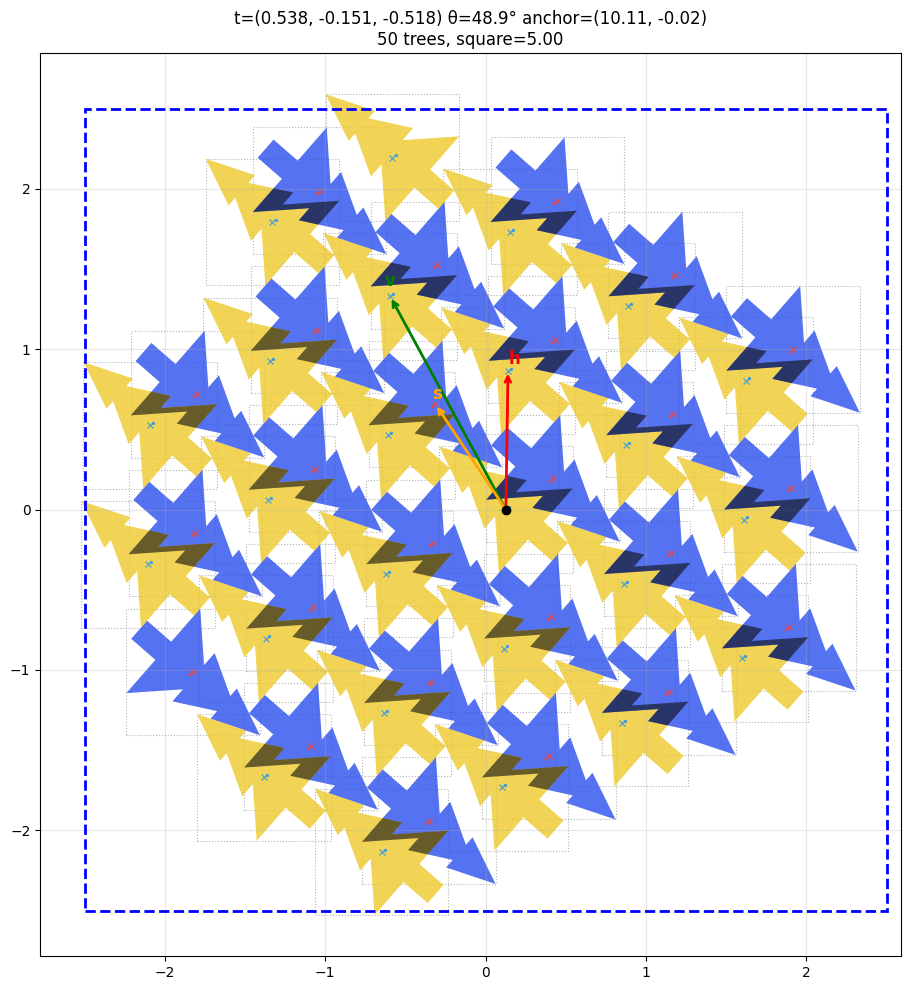

In [2]:
import viz_lattice

params = [5.3797060e-01, -1.5120809e-01, -5.1772255e-01, 4.8861443e+01, 1.0111742e+01, -2.4611901e-02]
viz_lattice.plot_lattice_from_params(params, n_trees=50, square_size=5.0)

In [ ]:

#import pack_test

#pack_test.test_costs()
#pack_test.run_all_tests(regenerate_reference=True)

# Run tests first
import pack_test_lattice
pack_test_lattice.run_all_tests()

# If tests pass, try an actual run
import pack_parametrized_lattice as ppl
runner = ppl.baseline_parametrized_lattice()
runner.ga.ga_base.N_trees_to_do = 50
runner.run()

Parametrized Lattice Tests
Testing NFP interpolation...
  ✓ NFP interpolation correct at waypoints and continuous
Testing cell vectors at t=0...
  ✓ Zero collision, cell area = 5376.0
Testing cell vector clamping across parameter sweep...
  ✓ 602/1000 (60.2%) collision-free after clamping
Testing scale factor...
  ✓ SCALE_FACTOR = 0.0125
Testing lattice generation...
  ✓ Generated 30 trees (requested 30)
Testing lattice rotation...
  ✓ Rotation changes positions (n=20 vs 20)
Testing extreme lattice params...
  ✓ Extreme params: 30 trees (no crash)
Testing SolutionCollection create_empty...
  ✓ create_empty preserves lattice fields
Testing SolutionCollection select_ids...
  ✓ select_ids slices lattice_params correctly
Testing SolutionCollection merge...
  ✓ merge concatenates lattice_params
Testing SolutionCollection clone...
  ✓ clone copies lattice_params correctly
Testing cost functions with lattice solution...
  ✓ AreaCost: cost=25.0000
  ✓ CollisionCostSeparation: cost=0.5333
  ✓ B

Loading cached lookup table from C:/GitHub/packing/temp//lut_cache/exact_sep_Nx900_Ny900_Nt900_trimTrue_tree42d0f17d.lut_cache...
Successfully loaded cached lookup table
n_inner: SolutionCollectionSquareParametrizedLattice(comment='', xyt=array([[[-0.78155476,  1.8041679 ,  3.0976975 ],
        [ 0.54740536, -1.7881238 ,  2.350907  ],
        [-1.6701727 ,  1.2814336 ,  0.6659053 ],
        [ 0.16568635,  0.41922542,  4.2427278 ],
        [ 1.7206882 ,  0.07299665,  5.4619584 ],
        [-0.68098974,  0.46926144,  2.1684608 ],
        [-0.6276468 ,  0.90103596,  1.9217366 ],
        [-0.14615993,  1.5711502 ,  2.7942991 ],
        [ 0.931553  , -1.4982536 ,  3.0112038 ],
        [ 1.6446348 , -0.8762825 ,  2.0215774 ],
        [ 1.5551426 , -0.41321218,  5.0543003 ],
        [-1.0298215 ,  1.5372493 ,  3.5239832 ],
        [-1.6949755 ,  0.80004096,  2.053155  ],
        [-0.21034439, -0.11258588,  0.05517735],
        [ 0.6153668 , -0.44677415,  2.1722655 ]]], dtype=float32), h=array(

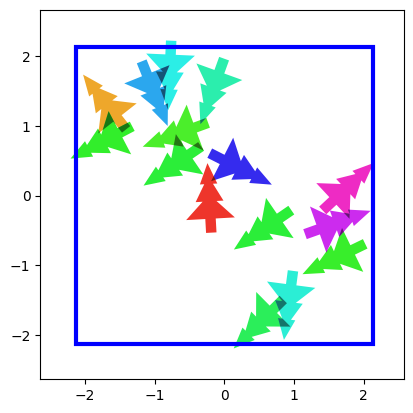

In [ ]:
import pack_parametrized_lattice as ppl
import pack_vis_sol
import cupy as cp

runner = ppl.baseline_parametrized_lattice()
runner.ga.ga_base.N_trees_to_do = 50

# Manual init only
runner._generator = cp.random.default_rng(seed=runner.seed)
runner.ga.fitness_cost = runner.fitness_cost
runner.ga.seed = runner.seed
runner.ga.initialize(runner._generator)
runner.ga.reset(runner._generator)
runner.ga.score(runner._generator, register_best=True)

# Visualize best after init+score, before any evolution
champion = runner.ga.best_ever[0]
pack_vis_sol.pack_vis_sol(champion.phenotype, solution_idx=0)
print("n_inner:", champion.genotype)

In [ ]:
import pack_parametrized_lattice as ppl
import pack_vis_sol

runner = ppl.baseline_parametrized_lattice()
runner.ga.ga_base.N_trees_to_do = 50
runner.n_generations = 1
runner.run()

champion = runner.ga.best_ever[0]
pack_vis_sol.pack_vis_sol(champion.phenotype, solution_idx=0)
print("lattice_params:", champion.genotype.lattice_params[0].get())
print("n_inner:", champion.genotype.n_inner)

Loading cached lookup table from C:/GitHub/packing/temp//lut_cache/exact_sep_Nx900_Ny900_Nt900_trimTrue_tree42d0f17d.lut_cache...
Successfully loaded cached lookup table
Generation 0: Best costs = [[0.330634, 1.7e-05]]
Before optimization:  0.16533392667770386 1.700086795608513e-05 4.0659184
After optimization:  0.0896623283624649 0.0007046633400022984 2.9825773
After optimization:  0.08893318474292755 0.00023438336211256683 2.9782345
After optimization:  0.08866602927446365 1.405193870596122e-05 2.9774482
After optimization:  0.08773311227560043 1.5949757653288543e-05 2.9617083
After optimization:  0.08741619437932968 2.026883976213867e-06 2.9565887
After optimization:  0.08739935606718063 8.651707048557e-07 2.9563236
After optimization:  0.0872301310300827 4.2137264699704247e-07 2.9534678
After optimization:  0.08717363327741623 7.327994211436817e-08 2.9525168
After optimization:  0.087187759578228 1.600170485005492e-08 2.9527571
After optimization:  0.08719363808631897 4.40376712873

<Axes: >

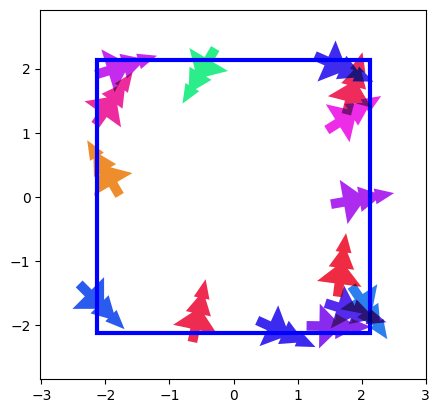

In [ ]:
pack_vis_sol.pack_vis_sol(champion.genotype, solution_idx=0)

In [4]:
# Check raw xyt of island 0's population
sol = runner.ga.best_ever[0].genotype
print("First individual:")
print(sol.xyt.get())

First individual:
[[[-1.7574626  -1.2082163   3.1467059 ]
  [-1.5096915   1.8715643   1.1914468 ]
  [-1.8916875   0.8163127  -3.5544293 ]
  [ 1.8294886  -1.2072589  -0.43767595]
  [ 1.2389807   1.5914935   0.80482346]
  [ 1.5542984   1.0732199   1.8803159 ]
  [-1.563184   -1.8561008   2.0560827 ]
  [-1.7306535   0.12049548 -6.4038987 ]
  [-0.9613979  -1.649643    6.5204554 ]
  [ 1.8884476   0.41155136  3.5377374 ]
  [ 1.865033    1.7173067   3.6166646 ]
  [ 0.84906083 -1.6706069   6.565013  ]
  [-0.01492813  1.834304    7.3721213 ]
  [ 1.7068343  -1.8697027   1.9224002 ]
  [-1.5777705   1.3610138   0.86750984]]]


[-0.03404345  0.20774566  0.3879015  20.857225   -2.2250593  15.11682   ]


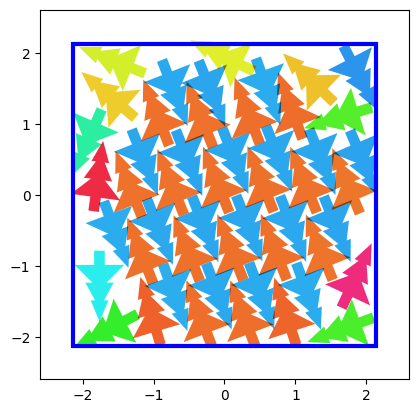

In [5]:
import pack_vis_sol
champion = runner.ga.best_ever[0]
pack_vis_sol.pack_vis_sol(champion.phenotype, solution_idx=0)
print(champion.genotype.lattice_params[0].get())

In [ ]:
# Tree positions (x, y, theta) for all trees
xyt = champion.genotype.xyt[0].get()  # (N_trees, 3)
print("Tree positions shape:", xyt.shape)
print(xyt)

# Boundary parameter (square size)
h = champion.genotype.h[0].get()
print("h:", h)

# How many are lattice vs edge
print("n_inner:", champion.genotype.n_inner)

Tree positions shape: (15, 3)
[[-0.55492556 -1.8536701   6.0759635 ]
 [ 1.8664259   1.6947378   6.0292153 ]
 [-1.990154    0.38376498  0.53020114]
 [-0.5000772   1.9521371   2.6052158 ]
 [ 1.8121457   1.2647139   5.2715516 ]
 [ 2.0760925  -1.7416252   3.7332695 ]
 [-1.7489341   2.0304472   5.0116754 ]
 [ 1.8319569  -1.7851969   4.4090858 ]
 [-2.1110678  -1.6563249   3.9286284 ]
 [ 1.6792223  -1.1410806   6.150815  ]
 [-1.9124433   1.4671514   5.6643066 ]
 [ 1.6522337   2.0298235   4.297237  ]
 [ 0.7513294  -2.1035714   4.283812  ]
 [ 1.9344006  -0.04227313  4.886544  ]
 [ 1.5599965  -2.0201542   4.6962967 ]]
h: [4.260441 0.       0.      ]
n_inner: 35


In [ ]:
import pack_parametrized_lattice as ppl
import numpy as np

# Denser packing — negative t values bring trees closer
xyt = ppl.generate_lattice_trees(
    t_same=0.0, t_horiz=0.0, t_vert=0.0,
    theta=0.0, anchor_dx=0.0, anchor_dy=0.0,
    n_inner=35, square_size=4.16, scale=ppl.SCALE_FACTOR
)
print(f"Trees generated: {len(xyt)}")
print(xyt.get())

Trees generated: 35
[[  0.35   0.2    0.  ]
 [ -0.35   0.2    0.  ]
 [  0.35  -0.2  180.  ]
 [ -0.35  -0.2  180.  ]
 [  0.     1.   180.  ]
 [  0.    -1.     0.  ]
 [ -0.7   -1.     0.  ]
 [  0.7    1.   180.  ]
 [ -0.7    1.   180.  ]
 [  0.7   -1.     0.  ]
 [  1.05   0.2    0.  ]
 [ -1.05   0.2    0.  ]
 [ -1.05  -0.2  180.  ]
 [  1.05  -0.2  180.  ]
 [  1.4   -1.     0.  ]
 [  1.4    1.   180.  ]
 [ -1.4   -1.     0.  ]
 [ -1.4    1.   180.  ]
 [  0.     1.4    0.  ]
 [  0.    -1.4  180.  ]
 [  1.75   0.2    0.  ]
 [  1.75  -0.2  180.  ]
 [ -1.75  -0.2  180.  ]
 [ -1.75   0.2    0.  ]
 [ -0.7    1.4    0.  ]
 [  0.7   -1.4  180.  ]
 [  0.7    1.4    0.  ]
 [ -0.7   -1.4  180.  ]
 [ -0.35  -2.2    0.  ]
 [  0.35   2.2  180.  ]
 [ -0.35   2.2  180.  ]
 [  0.35  -2.2    0.  ]
 [  1.05  -2.2    0.  ]
 [ -1.05  -2.2    0.  ]
 [ -1.05   2.2  180.  ]]


AttributeError: module 'pack_vis_sol' has no attribute 'plot_single_tree'

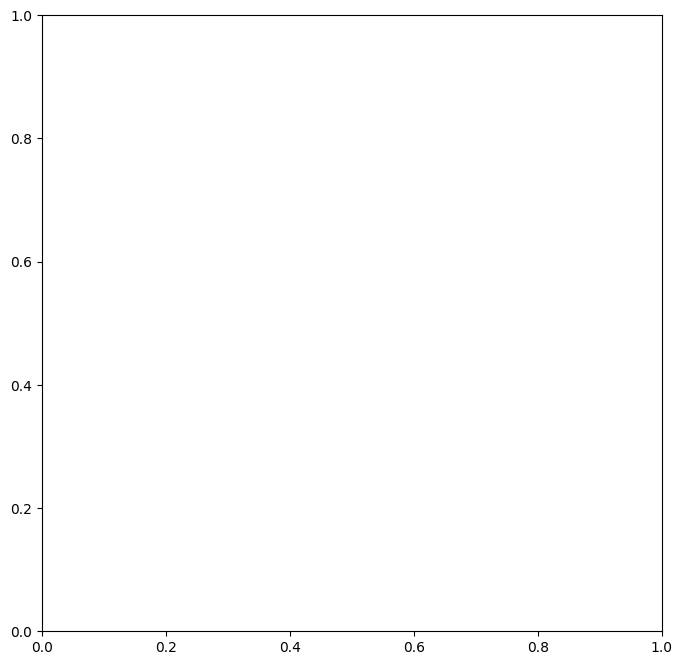

In [ ]:
import matplotlib.pyplot as plt
import pack_vis_sol

xyt_np = xyt.get()
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
for i in range(len(xyt_np)):
    pack_vis_sol.plot_single_tree(ax, xyt_np[i, 0], xyt_np[i, 1], xyt_np[i, 2])
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.add_patch(plt.Rectangle((-2.08, -2.08), 4.16, 4.16, fill=False, edgecolor='red'))
plt.show()